
# 02 - FDA Descriptive Analysis

## Aim of this notebook

This notebook uses the processed **FDA submission-event backbone** in `data/processed/fda_backbone.csv` to understand what the March 2026 Drugs@FDA extract actually affords for thesis analysis.

The goals here are descriptive and diagnostic:

- verify that the processed backbone looks internally consistent
- understand the unit of observation and what kinds of aggregation are safe
- map the broad time-series structure of FDA submission events
- summarize application type, submission type, approval status, sponsor patterns, and review-priority coding
- identify what this dataset can answer on its own and what enrichment layers are still needed

## Dataset used

The source for this notebook is the processed FDA master panel created in `01_fda_backbone_and_scope.ipynb`:

- `data/processed/fda_backbone.csv`

That processed file is intended to be an **unfiltered submission-event panel**. Each row should represent one submission event keyed by `ApplNo + SubmissionType + SubmissionNo`.

## What this notebook can and cannot answer

This notebook can describe:

- how many submission events appear in the processed FDA file over time
- how the observed mix of `ORIG` and `SUPPL` submissions changes over time
- how the observed mix of `NDA`, `ANDA`, `BLA`, and `UNKNOWN` application types changes over time
- how `AP` and `TA` statuses appear in the processed FDA data
- how sponsor concentration and some higher-level product/application descriptors look in the panel

This notebook cannot, by itself, establish:

- causal effects of PDUFA or any other policy
- the complete universe of failed FDA applications
- exact product-level approval histories for every submission
- whether an approved drug is a controlled substance

## Scope note

This is **exploratory descriptive work**, not causal analysis. The point is to learn what is in the FDA backbone before adding DEA schedule or other enrichment layers.


In [1]:

from pathlib import Path
from IPython.display import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.options.display.max_columns = 120
pd.options.display.float_format = lambda x: f"{x:,.3f}"
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.frameon"] = True


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "processed" / "fda_backbone.csv").exists() and (candidate / "code" / "notebooks").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate the repo root from the current working directory. "
        "Expected to find data/processed/fda_backbone.csv and code/notebooks in the repo."
    )


ROOT = find_repo_root()
BACKBONE_PATH = ROOT / "data" / "processed" / "fda_backbone.csv"
PDUFA_YEAR = 1992

print(f"Repo root: {ROOT}")
print(f"Processed FDA backbone: {BACKBONE_PATH}")


Repo root: /Users/alexdelatorre/Desktop/econ580-thesis
Processed FDA backbone: /Users/alexdelatorre/Desktop/econ580-thesis/data/processed/fda_backbone.csv



## Load the processed backbone and inspect the raw file as read from CSV

The first step is to inspect the processed CSV *as read from disk*, before making any working-copy adjustments for dates, identifiers, or boolean-like fields.

Aim:

- confirm the file loads
- inspect the shape and column list
- inspect dtypes as read from CSV
- look at the first few rows to verify that the file resembles the master panel described in the backbone notebook


In [2]:

fda_raw = pd.read_csv(BACKBONE_PATH, low_memory=False)

print("Raw file loaded successfully.")
print(f"Shape: {fda_raw.shape[0]:,} rows x {fda_raw.shape[1]:,} columns")

columns_df = pd.DataFrame({
    "column": fda_raw.columns,
    "dtype_as_read": fda_raw.dtypes.astype(str).values,
})

display(columns_df)
display(fda_raw.head(5))


Raw file loaded successfully.
Shape: 191,265 rows x 59 columns


,column,dtype_as_read
0,ApplNo,int64
1,ApplType_raw,object
2,ApplType_clean,object
3,ApplPublicNotes,object
4,SponsorName,object
5,SubmissionType,object
6,SubmissionNo,int64
7,SubmissionStatus,object
8,SubmissionStatusDate,object
9,submission_status_year,float64


,ApplNo,ApplType_raw,ApplType_clean,ApplPublicNotes,SponsorName,SubmissionType,SubmissionNo,SubmissionStatus,SubmissionStatusDate,submission_status_year,ReviewPriority_raw,ReviewPriority_clean,SubmissionClassCodeID,SubmissionClassCode,SubmissionClassCodeDescription,is_approved,is_tentative_approval,is_original_submission,n_submissions_total,n_orig_submissions,n_supplement_submissions,n_approved_submissions,n_tentative_submissions,first_submission_status_date,last_submission_status_date,first_approved_status_date,n_products,ProductNo_list,DrugName_list,ActiveIngredient_list,Form_list,Strength_list,ReferenceDrug_values,ReferenceStandard_values,n_marketing_status_rows,MarketingStatusID_list,MarketingStatusDescription_list,n_te_rows,TECode_list,TE_ProductNo_list,TE_MarketingStatusID_list,n_submission_property_rows,SubmissionPropertyTypeCode_list,SubmissionPropertyTypeID_list,has_orphan_property,n_action_rows,ActionTypes_LookupID_list,ActionTypes_LookupDescription_list,SupplCategoryLevel1Code_list,SupplCategoryLevel2Code_list,n_submission_docs,ApplicationDocsTypeID_list,ApplicationDocsTypeDescription_list,submission_doc_date_min,submission_doc_date_max,n_application_docs,ApplicationDocsTypeDescription_app_level,application_doc_date_min,application_doc_date_max
0,4,NDA,NDA,NaN,PHARMICS,ORIG,1,AP,1969-07-16,"1,969.000",UNKNOWN,UNKNOWN,19.000,UNKNOWN,NaN,True,False,True,3,1,2,3,0,1969-07-16,1987-05-26,1969-07-16,1.000,004,PAREDRINE,HYDROXYAMPHETAMINE HYDROBROMIDE,SOLUTION/DROPS;OPHTHALMIC,1%,0,0,1.000,3,Discontinued,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000,46,NaN,NaN,NOT APPLICABLE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4,NDA,NDA,NaN,PHARMICS,SUPPL,10,AP,1980-05-08,"1,980.000",NaN,UNKNOWN,3.000,LABELING,Labeling,True,False,False,3,1,2,3,0,1969-07-16,1987-05-26,1969-07-16,1.000,004,PAREDRINE,HYDROXYAMPHETAMINE HYDROBROMIDE,SOLUTION/DROPS;OPHTHALMIC,1%,0,0,1.000,3,Discontinued,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000,13,Labeling,LABELING,NOT APPLICABLE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4,NDA,NDA,NaN,PHARMICS,SUPPL,11,AP,1987-05-26,"1,987.000",NaN,UNKNOWN,3.000,LABELING,Labeling,True,False,False,3,1,2,3,0,1969-07-16,1987-05-26,1969-07-16,1.000,004,PAREDRINE,HYDROXYAMPHETAMINE HYDROBROMIDE,SOLUTION/DROPS;OPHTHALMIC,1%,0,0,1.000,3,Discontinued,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000,13,Labeling,LABELING,NOT APPLICABLE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,159,NDA,NDA,NaN,LILLY,ORIG,1,AP,1939-03-09,"1,939.000",NaN,UNKNOWN,NaN,NaN,NaN,True,False,True,3,1,2,3,0,1939-03-09,1986-12-09,1939-03-09,1.000,001,SULFAPYRIDINE,SULFAPYRIDINE,TABLET;ORAL,500MG,0,0,1.000,3,Discontinued,NaN,NaN,NaN,NaN,1.000,Null,0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,159,NDA,NDA,NaN,LILLY,SUPPL,3,AP,1986-12-09,"1,986.000",NaN,UNKNOWN,3.000,LABELING,Labeling,True,False,False,3,1,2,3,0,1939-03-09,1986-12-09,1939-03-09,1.000,001,SULFAPYRIDINE,SULFAPYRIDINE,TABLET;ORAL,500MG,0,0,1.000,3,Discontinued,NaN,NaN,NaN,NaN,1.000,Null,0,False,1.000,13,Labeling,LABELING,NOT APPLICABLE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



### Interpretation

The processed file loads as a wide submission-event panel with the expected backbone variables plus aggregated product, document, action-type, marketing-status, and TE fields.

A useful immediate finding is that CSV serialization has **not** preserved all analytical types cleanly:

- identifiers such as `ApplNo` are read back as numeric
- year fields are read as numeric floats
- boolean-like fields are read back as strings or generic objects
- date fields are read as strings

That is not a data-loss problem by itself, but it means the notebook should create a **working copy** with safer temporary types before doing descriptive analysis.



## Create a minimally cleaned working copy for descriptive analysis

This notebook does **not** modify the source CSV. Instead, it creates a temporary in-memory working copy with a few conservative adjustments:

- keep identifiers as strings
- parse date fields so time-series work is reliable
- convert boolean-like fields back into booleans where possible
- preserve raw categorical fields while adding filled helper variables for plotting and tabulation

These transformations are for analysis convenience only.


In [3]:

def clean_string_series(s: pd.Series) -> pd.Series:
    return (
        s.astype("string")
        .str.replace("﻿", "", regex=False)
        .str.strip()
        .replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})
    )


def parse_boolean_like(s: pd.Series) -> pd.Series:
    return (
        clean_string_series(s)
        .str.lower()
        .map({"true": True, "false": False})
        .astype("boolean")
    )


def first_nonmissing(s: pd.Series):
    s = s.dropna()
    return s.iloc[0] if len(s) else pd.NA


fda = fda_raw.copy()

string_cols = [
    "ApplNo",
    "ApplType_raw",
    "ApplType_clean",
    "ApplPublicNotes",
    "SponsorName",
    "SubmissionType",
    "SubmissionNo",
    "SubmissionStatus",
    "ReviewPriority_raw",
    "ReviewPriority_clean",
    "SubmissionClassCodeID",
    "SubmissionClassCode",
    "SubmissionClassCodeDescription",
    "ProductNo_list",
    "DrugName_list",
    "ActiveIngredient_list",
    "Form_list",
    "Strength_list",
    "ReferenceDrug_values",
    "ReferenceStandard_values",
    "MarketingStatusID_list",
    "MarketingStatusDescription_list",
    "TECode_list",
    "TE_ProductNo_list",
    "TE_MarketingStatusID_list",
    "SubmissionPropertyTypeCode_list",
    "SubmissionPropertyTypeID_list",
    "ActionTypes_LookupID_list",
    "ActionTypes_LookupDescription_list",
    "SupplCategoryLevel1Code_list",
    "SupplCategoryLevel2Code_list",
    "ApplicationDocsTypeID_list",
    "ApplicationDocsTypeDescription_list",
    "ApplicationDocsTypeDescription_app_level",
]

for col in string_cols:
    if col in fda.columns:
        fda[col] = clean_string_series(fda[col])

# Reconstruct the application identifier as a zero-padded string.
fda["ApplNo"] = clean_string_series(fda["ApplNo"]).str.zfill(6)
fda["SubmissionNo"] = clean_string_series(fda["SubmissionNo"])

numeric_cols = [
    "submission_status_year",
    "n_submissions_total",
    "n_orig_submissions",
    "n_supplement_submissions",
    "n_approved_submissions",
    "n_tentative_submissions",
    "n_products",
    "n_marketing_status_rows",
    "n_te_rows",
    "n_submission_property_rows",
    "n_action_rows",
    "n_submission_docs",
    "n_application_docs",
]

for col in numeric_cols:
    if col in fda.columns:
        fda[col] = pd.to_numeric(fda[col], errors="coerce").astype("Int64")

date_cols = [
    "SubmissionStatusDate",
    "first_submission_status_date",
    "last_submission_status_date",
    "first_approved_status_date",
    "submission_doc_date_min",
    "submission_doc_date_max",
    "application_doc_date_min",
    "application_doc_date_max",
]

for col in date_cols:
    if col in fda.columns:
        fda[col] = pd.to_datetime(fda[col], errors="coerce")

for col in ["is_approved", "is_tentative_approval", "is_original_submission", "has_orphan_property"]:
    if col in fda.columns:
        fda[col] = parse_boolean_like(fda[col])

# Filled helper fields keep the raw columns intact while making tabulation easier.
fda["submission_status_filled"] = fda["SubmissionStatus"].fillna("MISSING")
fda["submission_type_filled"] = fda["SubmissionType"].fillna("MISSING")
fda["appl_type_clean_filled"] = fda["ApplType_clean"].fillna("UNKNOWN")
fda["review_priority_raw_grouped"] = (
    fda["ReviewPriority_raw"]
    .fillna("MISSING")
    .replace({"901 REQUIRED": "OTHER_RAW_CODE", "901 ORDER": "OTHER_RAW_CODE"})
)
fda["review_priority_clean_filled"] = fda["ReviewPriority_clean"].fillna("MISSING")

fda["orphan_observation_status"] = pd.Series("Unclassified", index=fda.index, dtype="string")
fda.loc[fda["has_orphan_property"].eq(True).fillna(False), "orphan_observation_status"] = "Orphan property present"
fda.loc[fda["has_orphan_property"].eq(False).fillna(False), "orphan_observation_status"] = "No orphan property flagged"
fda.loc[fda["has_orphan_property"].isna(), "orphan_observation_status"] = "Missing property rows"

working_copy_summary = pd.DataFrame({
    "field": [
        "ApplNo",
        "SubmissionNo",
        "SubmissionStatusDate",
        "submission_status_year",
        "is_approved",
        "has_orphan_property",
    ],
    "dtype_in_working_copy": [
        str(fda["ApplNo"].dtype),
        str(fda["SubmissionNo"].dtype),
        str(fda["SubmissionStatusDate"].dtype),
        str(fda["submission_status_year"].dtype),
        str(fda["is_approved"].dtype),
        str(fda["has_orphan_property"].dtype),
    ],
})

display(working_copy_summary)
display(fda.head(3))


,field,dtype_in_working_copy
0,ApplNo,string
1,SubmissionNo,string
2,SubmissionStatusDate,datetime64[ns]
3,submission_status_year,Int64
4,is_approved,boolean
5,has_orphan_property,boolean


,ApplNo,ApplType_raw,ApplType_clean,ApplPublicNotes,SponsorName,SubmissionType,SubmissionNo,SubmissionStatus,SubmissionStatusDate,submission_status_year,ReviewPriority_raw,ReviewPriority_clean,SubmissionClassCodeID,SubmissionClassCode,SubmissionClassCodeDescription,is_approved,is_tentative_approval,is_original_submission,n_submissions_total,n_orig_submissions,n_supplement_submissions,n_approved_submissions,n_tentative_submissions,first_submission_status_date,last_submission_status_date,first_approved_status_date,n_products,ProductNo_list,DrugName_list,ActiveIngredient_list,Form_list,Strength_list,ReferenceDrug_values,ReferenceStandard_values,n_marketing_status_rows,MarketingStatusID_list,MarketingStatusDescription_list,n_te_rows,TECode_list,TE_ProductNo_list,TE_MarketingStatusID_list,n_submission_property_rows,SubmissionPropertyTypeCode_list,SubmissionPropertyTypeID_list,has_orphan_property,n_action_rows,ActionTypes_LookupID_list,ActionTypes_LookupDescription_list,SupplCategoryLevel1Code_list,SupplCategoryLevel2Code_list,n_submission_docs,ApplicationDocsTypeID_list,ApplicationDocsTypeDescription_list,submission_doc_date_min,submission_doc_date_max,n_application_docs,ApplicationDocsTypeDescription_app_level,application_doc_date_min,application_doc_date_max,submission_status_filled,submission_type_filled,appl_type_clean_filled,review_priority_raw_grouped,review_priority_clean_filled,orphan_observation_status
0,000004,NDA,NDA,<NA>,PHARMICS,ORIG,1,AP,1969-07-16,1969,UNKNOWN,UNKNOWN,19.0,UNKNOWN,<NA>,True,False,True,3,1,2,3,0,1969-07-16,1987-05-26,1969-07-16,1,004,PAREDRINE,HYDROXYAMPHETAMINE HYDROBROMIDE,SOLUTION/DROPS;OPHTHALMIC,1%,0,0,1,3,Discontinued,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1,46,<NA>,<NA>,NOT APPLICABLE,<NA>,<NA>,<NA>,NaT,NaT,<NA>,<NA>,NaT,NaT,AP,ORIG,NDA,UNKNOWN,UNKNOWN,Missing property rows
1,000004,NDA,NDA,<NA>,PHARMICS,SUPPL,10,AP,1980-05-08,1980,<NA>,UNKNOWN,3.0,LABELING,Labeling,True,False,False,3,1,2,3,0,1969-07-16,1987-05-26,1969-07-16,1,004,PAREDRINE,HYDROXYAMPHETAMINE HYDROBROMIDE,SOLUTION/DROPS;OPHTHALMIC,1%,0,0,1,3,Discontinued,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1,13,Labeling,LABELING,NOT APPLICABLE,<NA>,<NA>,<NA>,NaT,NaT,<NA>,<NA>,NaT,NaT,AP,SUPPL,NDA,MISSING,UNKNOWN,Missing property rows
2,000004,NDA,NDA,<NA>,PHARMICS,SUPPL,11,AP,1987-05-26,1987,<NA>,UNKNOWN,3.0,LABELING,Labeling,True,False,False,3,1,2,3,0,1969-07-16,1987-05-26,1969-07-16,1,004,PAREDRINE,HYDROXYAMPHETAMINE HYDROBROMIDE,SOLUTION/DROPS;OPHTHALMIC,1%,0,0,1,3,Discontinued,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1,13,Labeling,LABELING,NOT APPLICABLE,<NA>,<NA>,<NA>,NaT,NaT,<NA>,<NA>,NaT,NaT,AP,SUPPL,NDA,MISSING,UNKNOWN,Missing property rows



### Interpretation

The working copy is now better aligned with the actual structure of the dataset:

- `ApplNo` and `SubmissionNo` are treated as identifiers rather than measurements
- dates are parsed for time-series work
- boolean-like fields can now be summarized safely
- raw fields are still preserved, while helper fields make plotting cleaner

This is the right level of cleaning for a descriptive notebook. It improves readability without silently changing the underlying source file.



## Audit the key structure, missingness, and internal consistency of the processed backbone

Before producing descriptive statistics, it is worth checking whether the processed CSV still behaves like the full master panel built in the prior notebook.

Aim:

- verify uniqueness of the intended submission-event key
- inspect missingness in key fields
- inspect the observed categories for submission type and submission status
- check whether the file looks internally consistent with a full submission-event backbone


In [4]:

key_cols = ["ApplNo", "SubmissionType", "SubmissionNo"]

duplicate_key_count = int(fda.duplicated(key_cols).sum())
missing_key_rows = int(fda[key_cols].isna().any(axis=1).sum())

integrity_summary = pd.DataFrame({
    "check": [
        "rows in processed file",
        "columns in processed file",
        "distinct submission-event keys",
        "duplicate submission-event keys",
        "rows with any missing key component",
        "distinct application numbers",
        "distinct sponsor names",
        "min submission-status year",
        "max submission-status year",
    ],
    "value": [
        len(fda),
        fda.shape[1],
        fda[key_cols].drop_duplicates().shape[0],
        duplicate_key_count,
        missing_key_rows,
        fda["ApplNo"].nunique(dropna=True),
        fda["SponsorName"].nunique(dropna=True),
        fda["submission_status_year"].dropna().min(),
        fda["submission_status_year"].dropna().max(),
    ],
})

selected_missingness = (
    pd.DataFrame({
        "missing_n": fda[[
            "ApplNo",
            "SubmissionType",
            "SubmissionNo",
            "SubmissionStatus",
            "SubmissionStatusDate",
            "submission_status_year",
            "ApplType_raw",
            "ApplType_clean",
            "SponsorName",
            "DrugName_list",
            "ActiveIngredient_list",
            "ReviewPriority_raw",
            "ReviewPriority_clean",
            "SubmissionClassCode",
            "has_orphan_property",
        ]].isna().sum(),
        "missing_share": fda[[
            "ApplNo",
            "SubmissionType",
            "SubmissionNo",
            "SubmissionStatus",
            "SubmissionStatusDate",
            "submission_status_year",
            "ApplType_raw",
            "ApplType_clean",
            "SponsorName",
            "DrugName_list",
            "ActiveIngredient_list",
            "ReviewPriority_raw",
            "ReviewPriority_clean",
            "SubmissionClassCode",
            "has_orphan_property",
        ]].isna().mean().round(4),
    })
    .sort_values(["missing_share", "missing_n"], ascending=False)
)

observed_categories = {
    "SubmissionType": fda["submission_type_filled"].value_counts(dropna=False).to_dict(),
    "SubmissionStatus": fda["submission_status_filled"].value_counts(dropna=False).to_dict(),
    "ApplType_clean": fda["appl_type_clean_filled"].value_counts(dropna=False).to_dict(),
}

print("Observed categories")
for field, values in observed_categories.items():
    print(f"- {field}: {values}")

print()
display(integrity_summary)
display(selected_missingness)


Observed categories
- SubmissionType: {'SUPPL': 163831, 'ORIG': 27434}
- SubmissionStatus: {'AP': 190051, 'TA': 1213, 'MISSING': 1}
- ApplType_clean: {'ANDA': 99441, 'NDA': 80915, 'BLA': 5548, 'UNKNOWN': 5361}



,check,value
0,rows in processed file,191265
1,columns in processed file,65
2,distinct submission-event keys,191265
3,duplicate submission-event keys,0
4,rows with any missing key component,0
5,distinct application numbers,27662
6,distinct sponsor names,2205
7,min submission-status year,1939
8,max submission-status year,2026


,missing_n,missing_share
ReviewPriority_raw,82442,0.431
has_orphan_property,48442,0.253
SubmissionClassCode,12431,0.065
DrugName_list,5737,0.030
ActiveIngredient_list,5737,0.030
ApplType_raw,5361,0.028
SponsorName,5361,0.028
SubmissionStatusDate,6,0.000
submission_status_year,6,0.000
SubmissionStatus,1,0.000



### Interpretation

The key structural check is the most important one here: the processed file should behave like a **submission-event panel**, and the submission-event key should remain unique. If that holds, the backbone can support downstream descriptive work without obvious merge inflation.

The missingness table is also informative. Some missingness is expected because many variables come from supporting child tables rather than the core submissions table. In particular:

- missing `ReviewPriority_raw` does **not** mean missing submission events
- missing `DrugName_list` or `ActiveIngredient_list` can arise because product information was attached conservatively at the application level
- missing `has_orphan_property` usually means there were no submission-property rows to evaluate, not necessarily that the submission was non-orphan

So the notebook should interpret missingness as a feature of the source architecture, not automatically as data failure.



## High-level counts: how large is this panel and how many distinct entities does it cover?

The panel is keyed at the submission-event level, but it is still useful to summarize how many distinct applications, sponsors, and drug/ingredient aggregates appear in it.


In [5]:

entity_summary = pd.DataFrame({
    "metric": [
        "submission-event rows",
        "distinct application numbers",
        "distinct sponsor names",
        "distinct drug-name aggregates",
        "distinct active-ingredient aggregates",
        "distinct application numbers with at least one AP row",
        "distinct application numbers with at least one TA row",
    ],
    "value": [
        len(fda),
        fda["ApplNo"].nunique(dropna=True),
        fda["SponsorName"].nunique(dropna=True),
        fda["DrugName_list"].nunique(dropna=True),
        fda["ActiveIngredient_list"].nunique(dropna=True),
        fda.loc[fda["is_approved"].fillna(False), "ApplNo"].nunique(),
        fda.loc[fda["is_tentative_approval"].fillna(False), "ApplNo"].nunique(),
    ],
})

display(entity_summary)


,metric,value
0,submission-event rows,191265
1,distinct application numbers,27662
2,distinct sponsor names,2205
3,distinct drug-name aggregates,7152
4,distinct active-ingredient aggregates,3202
5,distinct application numbers with at least one...,26539
6,distinct application numbers with at least one...,1201



### Interpretation

These counts help separate the size of the **panel** from the size of the underlying regulatory universe. The notebook is not looking at 191 thousand distinct drugs or applications. It is looking at 191 thousand **submission events** attached to a smaller set of applications, sponsors, and application-level product descriptors.

That distinction matters for every figure that follows. High submission counts can reflect repeat supplements to the same application rather than growth in distinct drugs.



## Submission-event counts over time

This is the broadest time-series view of the processed file: how many submission events are observed in each status year.

Caveat up front: this is **not** a series of new drug approvals or new applications filed. It is a series of observed **submission events** in the processed FDA backbone.


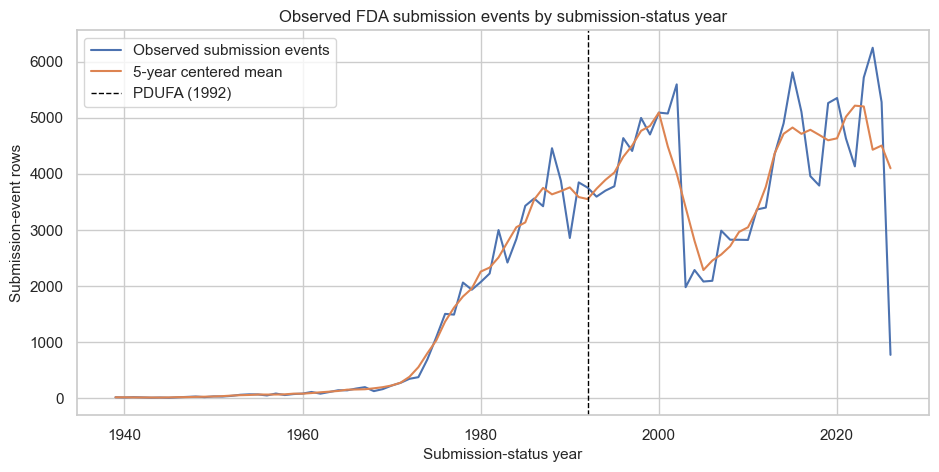

,submission_status_year,submission_events,five_year_centered_mean
0,1939,15,14.000
1,1940,11,13.500
2,1941,16,12.200
3,1942,12,11.200
4,1943,7,10.200
5,1944,10,9.800
6,1945,6,11.600
7,1946,14,15.800
8,1947,21,17.200
9,1948,28,22.000


,submission_status_year,submission_events,five_year_centered_mean
78,2017,3959,"4,785.800"
79,2018,3791,"4,694.200"
80,2019,5262,"4,598.800"
81,2020,5352,"4,633.600"
82,2021,4630,"5,019.000"
83,2022,4133,"5,216.400"
84,2023,5718,"5,201.800"
85,2024,6249,"4,430.000"
86,2025,5279,"4,504.250"
87,2026,771,"4,099.667"


In [6]:

submission_counts_year = (
    fda.dropna(subset=["submission_status_year"])
    .groupby("submission_status_year", dropna=False)
    .size()
    .reset_index(name="submission_events")
    .sort_values("submission_status_year")
)
submission_counts_year["submission_status_year"] = submission_counts_year["submission_status_year"].astype(int)
submission_counts_year["five_year_centered_mean"] = (
    submission_counts_year["submission_events"]
    .rolling(window=5, center=True, min_periods=1)
    .mean()
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(submission_counts_year["submission_status_year"], submission_counts_year["submission_events"], label="Observed submission events")
ax.plot(submission_counts_year["submission_status_year"], submission_counts_year["five_year_centered_mean"], label="5-year centered mean")
ax.axvline(PDUFA_YEAR, color="black", linestyle="--", linewidth=1, label=f"PDUFA ({PDUFA_YEAR})")
ax.set_title("Observed FDA submission events by submission-status year")
ax.set_xlabel("Submission-status year")
ax.set_ylabel("Submission-event rows")
ax.legend()
plt.show()

display(submission_counts_year.head(10))
display(submission_counts_year.tail(10))



### Interpretation

This figure is useful for understanding the **volume of regulatory activity recorded in the panel**, but it should not be read as a count of unique drugs. The main thing it reveals is how dense the submission-event history becomes over time.

If later figures show large increases in counts after the early 1990s, one plausible reason is genuine regulatory growth. Another is that the panel becomes increasingly supplement-heavy. The next sections separate those possibilities.



## Approval-status counts over time

Because Drugs@FDA is approval-centered, it is important to see how often the processed file records `AP`, `TA`, or missing status values over time.

Here the notebook looks at both counts and shares. The share view is especially useful because `TA` rows are much rarer than `AP` rows.


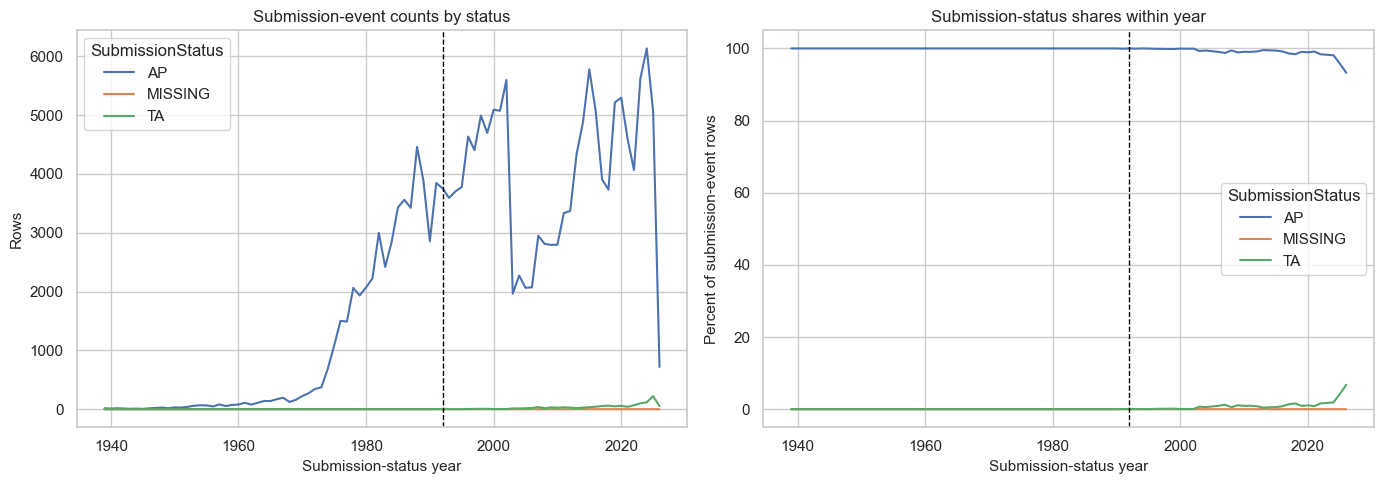

submission_status_filled,AP,MISSING,TA
submission_status_year,,,
2015,"5,776.000",0.000,34.000
2016,"5,065.000",0.000,42.000
2017,"3,904.000",0.000,55.000
2018,"3,731.000",0.000,60.000
2019,"5,213.000",0.000,49.000
2020,"5,295.000",0.000,57.000
2021,"4,590.000",0.000,40.000
2022,"4,066.000",0.000,67.000
2023,"5,618.000",0.000,100.000


In [7]:

status_year = (
    fda.dropna(subset=["submission_status_year"])
    .groupby(["submission_status_year", "submission_status_filled"], dropna=False)
    .size()
    .reset_index(name="n")
)
status_year["submission_status_year"] = status_year["submission_status_year"].astype(int)
status_year["share_within_year"] = status_year["n"] / status_year.groupby("submission_status_year")["n"].transform("sum")

status_pivot = status_year.pivot(index="submission_status_year", columns="submission_status_filled", values="n").fillna(0)
status_share_pivot = status_year.pivot(index="submission_status_year", columns="submission_status_filled", values="share_within_year").fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for col in status_pivot.columns:
    axes[0].plot(status_pivot.index, status_pivot[col], label=col)
axes[0].axvline(PDUFA_YEAR, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Submission-event counts by status")
axes[0].set_xlabel("Submission-status year")
axes[0].set_ylabel("Rows")
axes[0].legend(title="SubmissionStatus")

for col in status_share_pivot.columns:
    axes[1].plot(status_share_pivot.index, status_share_pivot[col] * 100, label=col)
axes[1].axvline(PDUFA_YEAR, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Submission-status shares within year")
axes[1].set_xlabel("Submission-status year")
axes[1].set_ylabel("Percent of submission-event rows")
axes[1].legend(title="SubmissionStatus")

plt.tight_layout()
plt.show()

display(status_pivot.tail(12))



### Interpretation

The status plots are most useful as a reminder that the processed file is not a balanced universe of all possible regulatory outcomes. If `AP` dominates overwhelmingly, that is telling us something real about the source: the Drugs@FDA extract is oriented around approved products and closely related regulatory activity.

That means later thesis claims should avoid language that treats this panel as a complete history of unsuccessful FDA filings. It is much better suited to describing the **composition of observed approval-related regulatory activity**.



## Submission type over time: original submissions versus supplements

The master panel is likely to be dominated by supplements, and that matters a great deal for interpretation.

This section makes that explicit by plotting both counts and the within-year share of `ORIG` rows. The share plot is often more informative than the count plot because supplements can dominate the level series.


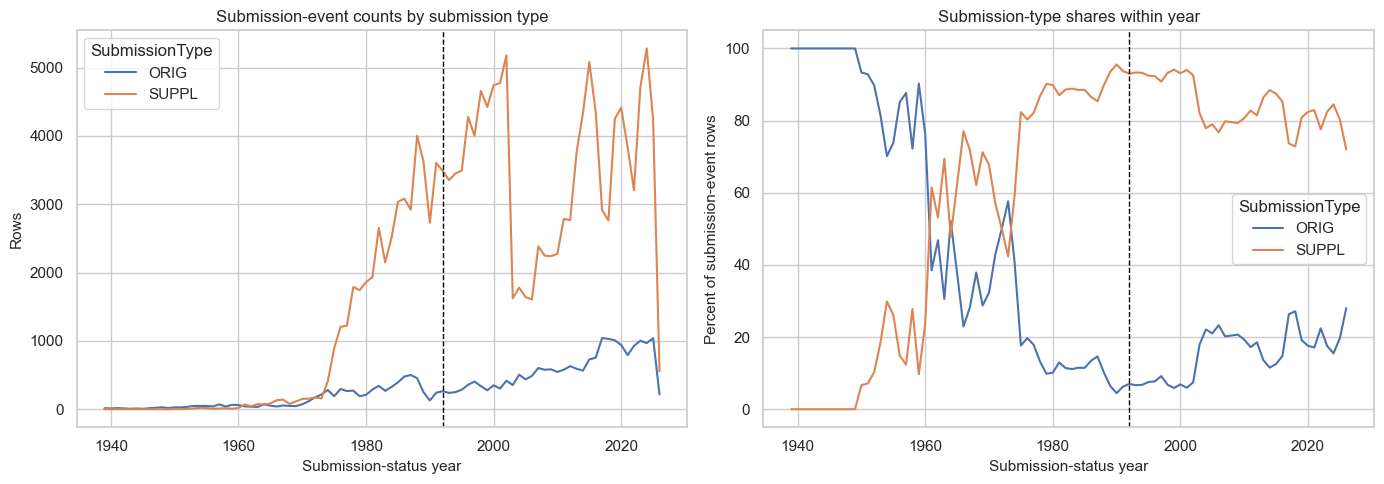

,period,submission_type_filled,n,share_within_period
0,1992 and after,ORIG,20390,0.144
1,1992 and after,SUPPL,120909,0.856
2,Before 1992,ORIG,7041,0.141
3,Before 1992,SUPPL,42919,0.859


In [8]:

submission_type_year = (
    fda.dropna(subset=["submission_status_year"])
    .groupby(["submission_status_year", "submission_type_filled"], dropna=False)
    .size()
    .reset_index(name="n")
)
submission_type_year["submission_status_year"] = submission_type_year["submission_status_year"].astype(int)
submission_type_year["share_within_year"] = (
    submission_type_year["n"]
    / submission_type_year.groupby("submission_status_year")["n"].transform("sum")
)

submission_type_counts = submission_type_year.pivot(index="submission_status_year", columns="submission_type_filled", values="n").fillna(0)
submission_type_shares = submission_type_year.pivot(index="submission_status_year", columns="submission_type_filled", values="share_within_year").fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for col in submission_type_counts.columns:
    axes[0].plot(submission_type_counts.index, submission_type_counts[col], label=col)
axes[0].axvline(PDUFA_YEAR, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Submission-event counts by submission type")
axes[0].set_xlabel("Submission-status year")
axes[0].set_ylabel("Rows")
axes[0].legend(title="SubmissionType")

for col in submission_type_shares.columns:
    axes[1].plot(submission_type_shares.index, submission_type_shares[col] * 100, label=col)
axes[1].axvline(PDUFA_YEAR, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Submission-type shares within year")
axes[1].set_xlabel("Submission-status year")
axes[1].set_ylabel("Percent of submission-event rows")
axes[1].legend(title="SubmissionType")

plt.tight_layout()
plt.show()

pre_post_base = fda.dropna(subset=["submission_status_year"]).copy()
pre_post_base["period"] = np.where(
    pre_post_base["submission_status_year"].astype(int) < PDUFA_YEAR,
    f"Before {PDUFA_YEAR}",
    f"{PDUFA_YEAR} and after",
)

pre_post_submission_type = (
    pre_post_base
    .groupby(["period", "submission_type_filled"], dropna=False)
    .size()
    .reset_index(name="n")
)
pre_post_submission_type["share_within_period"] = (
    pre_post_submission_type["n"]
    / pre_post_submission_type.groupby("period")["n"].transform("sum")
)

display(pre_post_submission_type)



### Interpretation

This is one of the most important unit-of-observation checks in the notebook. If supplements dominate the panel, then many simple counts are mostly describing **repeat regulatory activity within existing applications** rather than the arrival of new drugs.

That does not make the panel uninformative. It just means that, for thesis questions about the composition of newly approved drugs, later analyses will probably need to compare the full panel against narrower subsets such as `ORIG`, `AP`, or `ORIG + AP`.



## Application type over time

The submission-event panel contains application-level type labels such as `NDA`, `ANDA`, and `BLA`. Because the panel is at the submission-event level, these figures describe the **mix of submission events by application type**, not the mix of distinct applications.

That is still useful for understanding the broad character of the FDA activity captured here.


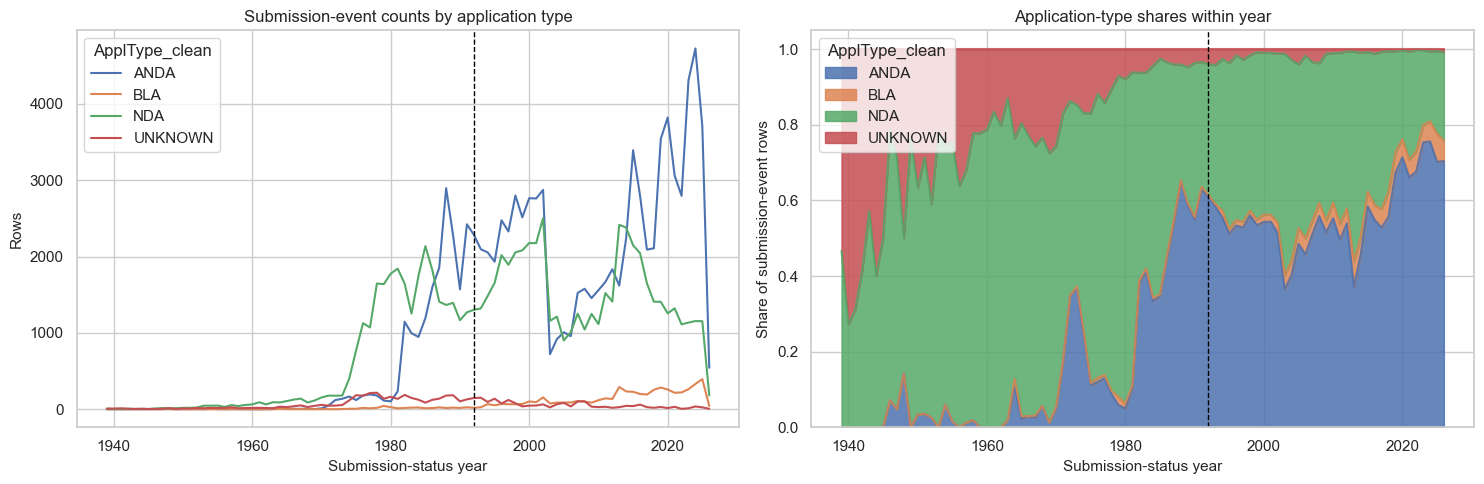

appl_type_clean_filled,ANDA,BLA,NDA,UNKNOWN
submission_status_year,,,,
1980,0.050,0.013,0.858,0.079
1985,0.348,0.004,0.623,0.025
1990,0.550,0.006,0.408,0.036
1992,0.609,0.005,0.347,0.039
1995,0.512,0.014,0.438,0.037
2000,0.543,0.020,0.428,0.009
2010,0.553,0.042,0.395,0.010
2020,0.714,0.048,0.235,0.003
2025,0.702,0.075,0.218,0.005


In [9]:

application_type_year = (
    fda.dropna(subset=["submission_status_year"])
    .groupby(["submission_status_year", "appl_type_clean_filled"], dropna=False)
    .size()
    .reset_index(name="n")
)
application_type_year["submission_status_year"] = application_type_year["submission_status_year"].astype(int)
application_type_year["share_within_year"] = (
    application_type_year["n"]
    / application_type_year.groupby("submission_status_year")["n"].transform("sum")
)

application_type_counts = application_type_year.pivot(index="submission_status_year", columns="appl_type_clean_filled", values="n").fillna(0)
application_type_shares = application_type_year.pivot(index="submission_status_year", columns="appl_type_clean_filled", values="share_within_year").fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for col in application_type_counts.columns:
    axes[0].plot(application_type_counts.index, application_type_counts[col], label=col)
axes[0].axvline(PDUFA_YEAR, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Submission-event counts by application type")
axes[0].set_xlabel("Submission-status year")
axes[0].set_ylabel("Rows")
axes[0].legend(title="ApplType_clean")

application_type_shares.plot.area(ax=axes[1], alpha=0.85)
axes[1].axvline(PDUFA_YEAR, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Application-type shares within year")
axes[1].set_xlabel("Submission-status year")
axes[1].set_ylabel("Share of submission-event rows")
axes[1].legend(title="ApplType_clean", loc="upper left")

plt.tight_layout()
plt.show()

selected_years = [1980, 1985, 1990, 1992, 1995, 2000, 2010, 2020, 2025]
selected_application_type_shares = (
    application_type_shares.loc[application_type_shares.index.isin(selected_years)]
    .round(3)
)

display(selected_application_type_shares)



### Interpretation

This section is informative about the broad regulatory composition of the panel. If `ANDA` shares rise over time, that suggests the processed backbone increasingly reflects generic-drug regulatory activity. That matters for the thesis because changes in observed controlled-substance composition could reflect shifts in the overall FDA regulatory mix rather than only shifts in approval speed.

The key caveat remains the unit of observation: these are **submission-event shares**, not application-level shares. Sponsors or application types that generate many supplements can look especially important in this view.



## Review priority: raw coding quality and cleaned categories

`ReviewPriority` is potentially informative for the thesis, but it should be treated carefully.

This section does two things:

1. inspect the **raw** field to see how much missingness or odd coding remains
2. inspect the **cleaned** field over time, both in the full panel and in a narrower `ORIG + AP` subset where the concept is often more substantively interpretable


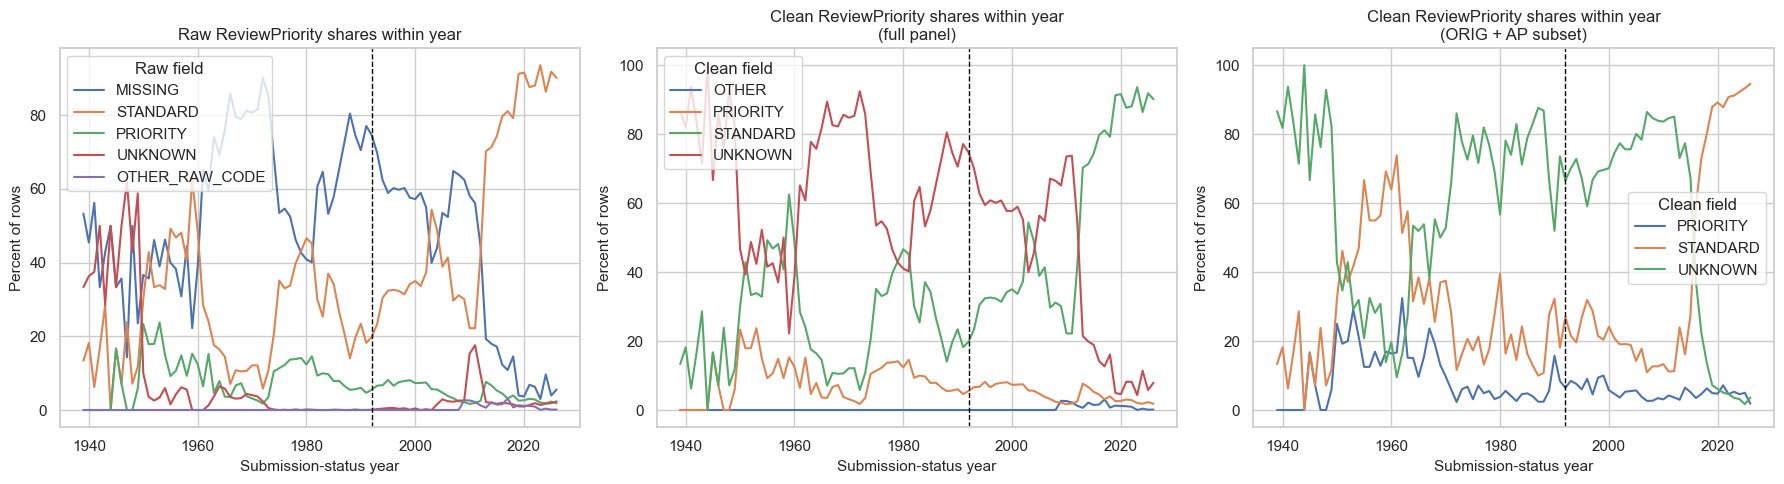

,review_priority_raw_grouped,n,share
0,STANDARD,93661,0.490
1,MISSING,82442,0.431
2,PRIORITY,11092,0.058
3,UNKNOWN,3108,0.016
4,OTHER_RAW_CODE,962,0.005


In [10]:

review_raw_summary = (
    fda["review_priority_raw_grouped"]
    .value_counts(dropna=False)
    .rename_axis("review_priority_raw_grouped")
    .reset_index(name="n")
)
review_raw_summary["share"] = (review_raw_summary["n"] / len(fda)).round(4)

review_raw_year = (
    fda.dropna(subset=["submission_status_year"])
    .groupby(["submission_status_year", "review_priority_raw_grouped"], dropna=False)
    .size()
    .reset_index(name="n")
)
review_raw_year["submission_status_year"] = review_raw_year["submission_status_year"].astype(int)
review_raw_year["share_within_year"] = (
    review_raw_year["n"]
    / review_raw_year.groupby("submission_status_year")["n"].transform("sum")
)
review_raw_year_pivot = review_raw_year.pivot(index="submission_status_year", columns="review_priority_raw_grouped", values="share_within_year").fillna(0)

review_clean_year = (
    fda.dropna(subset=["submission_status_year"])
    .groupby(["submission_status_year", "review_priority_clean_filled"], dropna=False)
    .size()
    .reset_index(name="n")
)
review_clean_year["submission_status_year"] = review_clean_year["submission_status_year"].astype(int)
review_clean_year["share_within_year"] = (
    review_clean_year["n"]
    / review_clean_year.groupby("submission_status_year")["n"].transform("sum")
)
review_clean_year_pivot = review_clean_year.pivot(index="submission_status_year", columns="review_priority_clean_filled", values="share_within_year").fillna(0)

orig_ap = fda.loc[
    fda["SubmissionType"].eq("ORIG") & fda["SubmissionStatus"].eq("AP")
].copy()

orig_ap_review_year = (
    orig_ap.dropna(subset=["submission_status_year"])
    .groupby(["submission_status_year", "review_priority_clean_filled"], dropna=False)
    .size()
    .reset_index(name="n")
)
orig_ap_review_year["submission_status_year"] = orig_ap_review_year["submission_status_year"].astype(int)
orig_ap_review_year["share_within_year"] = (
    orig_ap_review_year["n"]
    / orig_ap_review_year.groupby("submission_status_year")["n"].transform("sum")
)
orig_ap_review_year_pivot = orig_ap_review_year.pivot(index="submission_status_year", columns="review_priority_clean_filled", values="share_within_year").fillna(0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
review_raw_cols = [col for col in ["MISSING", "STANDARD", "PRIORITY", "UNKNOWN", "OTHER_RAW_CODE"] if col in review_raw_year_pivot.columns]
for col in review_raw_cols:
    axes[0].plot(review_raw_year_pivot.index, review_raw_year_pivot[col] * 100, label=col)
axes[0].axvline(PDUFA_YEAR, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Raw ReviewPriority shares within year")
axes[0].set_xlabel("Submission-status year")
axes[0].set_ylabel("Percent of rows")
axes[0].legend(title="Raw field")

for col in review_clean_year_pivot.columns:
    axes[1].plot(review_clean_year_pivot.index, review_clean_year_pivot[col] * 100, label=col)
axes[1].axvline(PDUFA_YEAR, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Clean ReviewPriority shares within year\n(full panel)")
axes[1].set_xlabel("Submission-status year")
axes[1].set_ylabel("Percent of rows")
axes[1].legend(title="Clean field")

for col in orig_ap_review_year_pivot.columns:
    axes[2].plot(orig_ap_review_year_pivot.index, orig_ap_review_year_pivot[col] * 100, label=col)
axes[2].axvline(PDUFA_YEAR, color="black", linestyle="--", linewidth=1)
axes[2].set_title("Clean ReviewPriority shares within year\n(ORIG + AP subset)")
axes[2].set_xlabel("Submission-status year")
axes[2].set_ylabel("Percent of rows")
axes[2].legend(title="Clean field")

plt.tight_layout()
plt.show()

display(review_raw_summary)



### Interpretation

The raw review-priority field is useful partly because it reveals **coding quality**. Large missing shares or changes in coding conventions over time can make naive trend interpretation misleading.

The cleaned field is better for broad descriptive summaries, but it still should not be over-interpreted mechanically. The `ORIG + AP` sensitivity plot is helpful because it shifts attention closer to new-approval activity rather than the supplement-heavy full panel. If the full-panel and `ORIG + AP` views differ materially, that is substantive information about the importance of the unit of observation.



## Sponsor concentration

Submission-event panels can make repeat filers look disproportionately large because one application can generate many supplement rows. To make that visible, this section compares sponsor concentration using two units:

- **submission-event rows**
- **distinct applications**

That comparison helps separate persistent regulatory activity from the breadth of a sponsor's application footprint.


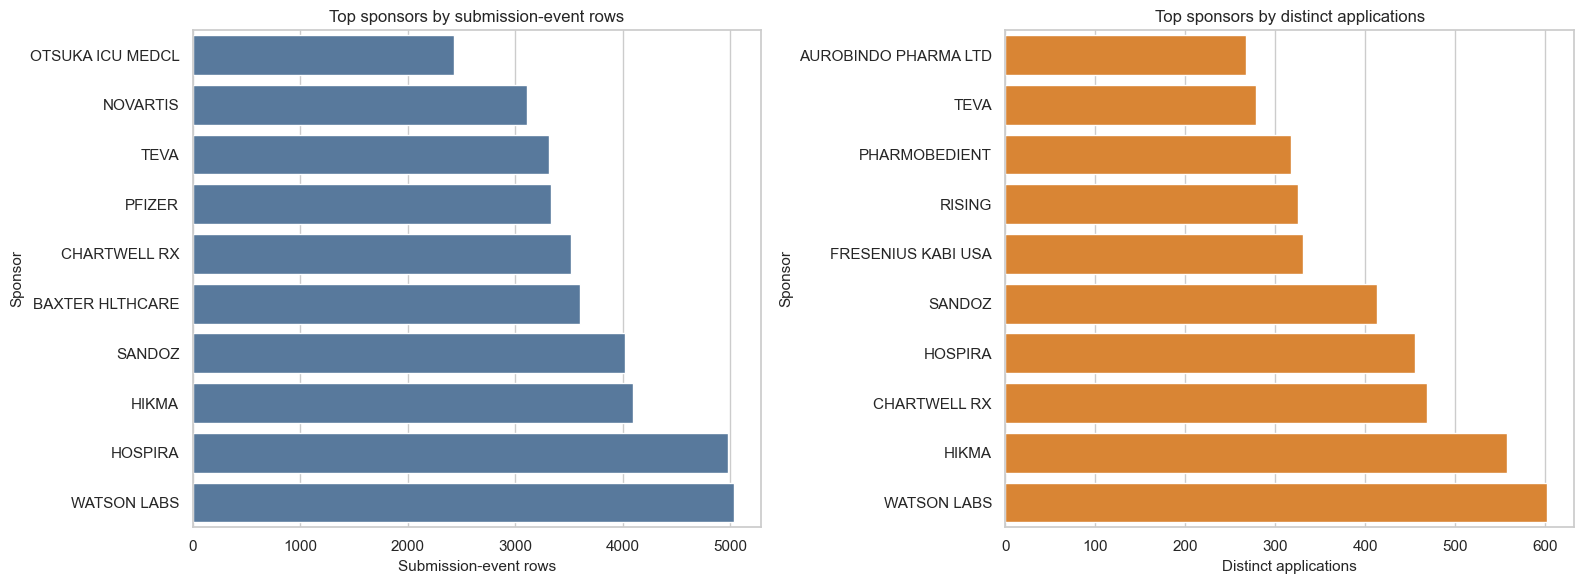

,metric,value
0,top 10 sponsor share of submission-event rows,0.196
1,top 10 sponsor share of distinct applications,0.145
2,distinct sponsors in submission-event panel,"2,205.000"


In [11]:

sponsor_submission_counts = (
    fda["SponsorName"]
    .value_counts(dropna=True)
    .rename_axis("SponsorName")
    .reset_index(name="submission_event_rows")
)

application_panel_for_sponsors = (
    fda.sort_values(["ApplNo", "SubmissionStatusDate"])
    .groupby("ApplNo", dropna=False)
    .agg(SponsorName=("SponsorName", first_nonmissing))
    .reset_index()
)

sponsor_application_counts = (
    application_panel_for_sponsors["SponsorName"]
    .value_counts(dropna=True)
    .rename_axis("SponsorName")
    .reset_index(name="distinct_applications")
)

submission_top10 = sponsor_submission_counts.head(10).copy()
application_top10 = sponsor_application_counts.head(10).copy()

submission_top10_share = submission_top10["submission_event_rows"].sum() / len(fda)
application_top10_share = application_top10["distinct_applications"].sum() / len(application_panel_for_sponsors)

concentration_summary = pd.DataFrame({
    "metric": [
        "top 10 sponsor share of submission-event rows",
        "top 10 sponsor share of distinct applications",
        "distinct sponsors in submission-event panel",
    ],
    "value": [
        round(submission_top10_share, 4),
        round(application_top10_share, 4),
        fda["SponsorName"].nunique(dropna=True),
    ],
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=submission_top10.sort_values("submission_event_rows", ascending=True), x="submission_event_rows", y="SponsorName", ax=axes[0], color="#4C78A8")
axes[0].set_title("Top sponsors by submission-event rows")
axes[0].set_xlabel("Submission-event rows")
axes[0].set_ylabel("Sponsor")

sns.barplot(data=application_top10.sort_values("distinct_applications", ascending=True), x="distinct_applications", y="SponsorName", ax=axes[1], color="#F58518")
axes[1].set_title("Top sponsors by distinct applications")
axes[1].set_xlabel("Distinct applications")
axes[1].set_ylabel("Sponsor")

plt.tight_layout()
plt.show()

display(concentration_summary)



### Interpretation

This comparison is mainly a warning against over-reading sponsor rankings from the raw panel alone. A sponsor can appear large because it has many applications, because it files many supplements per application, or both.

If the top-sponsor list changes materially when the unit shifts from submission rows to distinct applications, that is exactly the kind of pattern a careful descriptive notebook should surface rather than hide.



## Orphan-property signal

The processed backbone includes an orphan-related indicator derived from `SubmissionPropertyType`. This is potentially useful, but it requires caution because missing property rows are common.

So this section reports orphan information in two ways:

- across the full panel, where missing property rows remain visible
- among rows that have any observed submission-property information, where the orphan flag is more interpretable


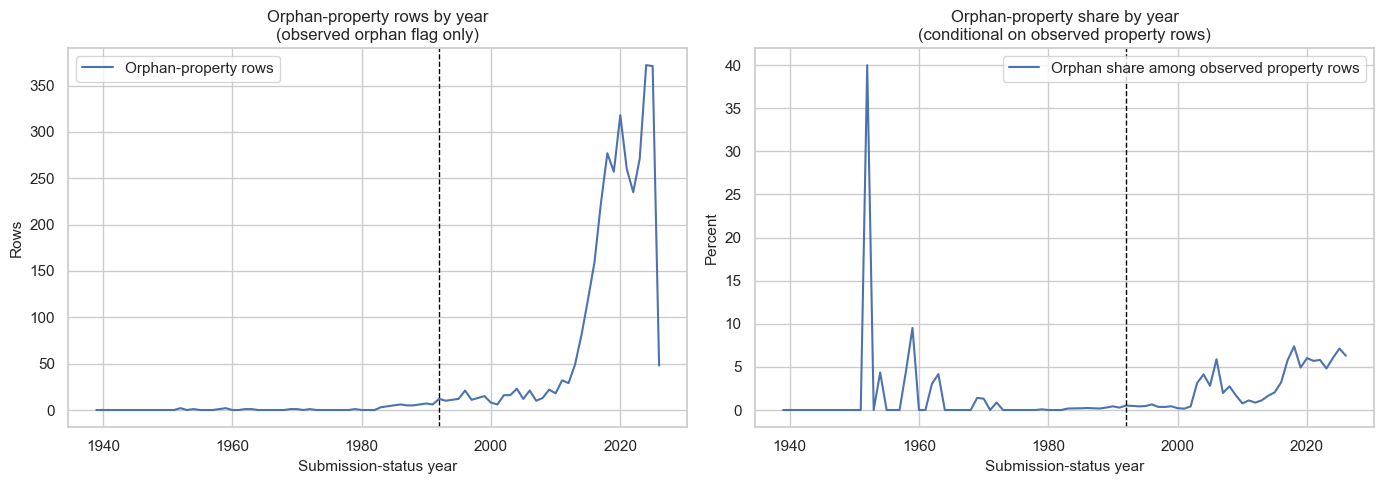

,metric,value
0,all submission-event rows,"191,265.000"
1,rows with any observed submission-property inf...,"142,823.000"
2,rows flagged with orphan property,"3,430.000"
3,share orphan among all submission-event rows,0.024
4,share orphan among rows with observed property...,0.024


In [12]:

orphan_summary = pd.DataFrame({
    "metric": [
        "all submission-event rows",
        "rows with any observed submission-property information",
        "rows flagged with orphan property",
        "share orphan among all submission-event rows",
        "share orphan among rows with observed property information",
    ],
    "value": [
        len(fda),
        int(fda["has_orphan_property"].notna().sum()),
        int(fda["has_orphan_property"].eq(True).sum()),
        round(float(fda["has_orphan_property"].eq(True).mean()), 4),
        round(float(fda.loc[fda["has_orphan_property"].notna(), "has_orphan_property"].eq(True).mean()), 4),
    ],
})

orphan_year_observed = (
    fda.loc[fda["has_orphan_property"].notna() & fda["submission_status_year"].notna()]
    .groupby("submission_status_year")
    .agg(
        observed_property_rows=("has_orphan_property", "size"),
        orphan_rows=("has_orphan_property", lambda s: s.eq(True).sum()),
    )
    .reset_index()
)
orphan_year_observed["submission_status_year"] = orphan_year_observed["submission_status_year"].astype(int)
orphan_year_observed["orphan_share_observed"] = orphan_year_observed["orphan_rows"] / orphan_year_observed["observed_property_rows"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(orphan_year_observed["submission_status_year"], orphan_year_observed["orphan_rows"], label="Orphan-property rows")
axes[0].axvline(PDUFA_YEAR, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Orphan-property rows by year\n(observed orphan flag only)")
axes[0].set_xlabel("Submission-status year")
axes[0].set_ylabel("Rows")
axes[0].legend()

axes[1].plot(orphan_year_observed["submission_status_year"], orphan_year_observed["orphan_share_observed"] * 100, label="Orphan share among observed property rows")
axes[1].axvline(PDUFA_YEAR, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Orphan-property share by year\n(conditional on observed property rows)")
axes[1].set_xlabel("Submission-status year")
axes[1].set_ylabel("Percent")
axes[1].legend()

plt.tight_layout()
plt.show()

display(orphan_summary)



### Interpretation

This is a useful early screen, but not a definitive orphan-designation dataset. The safest interpretation is conditional: among the rows where submission-property information is observed, how often does an orphan-related property appear?

That is informative for exploratory work, but missing property rows should not be treated as evidence that a submission is non-orphan. If orphan status becomes central later, it will deserve a separate validation step.



## Application-level sensitivity check

Up to this point, the notebook has been explicit about the fact that the processed file is a **submission-event** panel. It is still useful, though, to create a temporary **application-level** view for sensitivity checks.

This aggregation is justified only for descriptive purposes. The application-level panel below uses one row per `ApplNo` and defines `first_observed_status_year` as the earliest status year seen in the processed panel.

Important caveat: that is **not** the same as original application filing year.


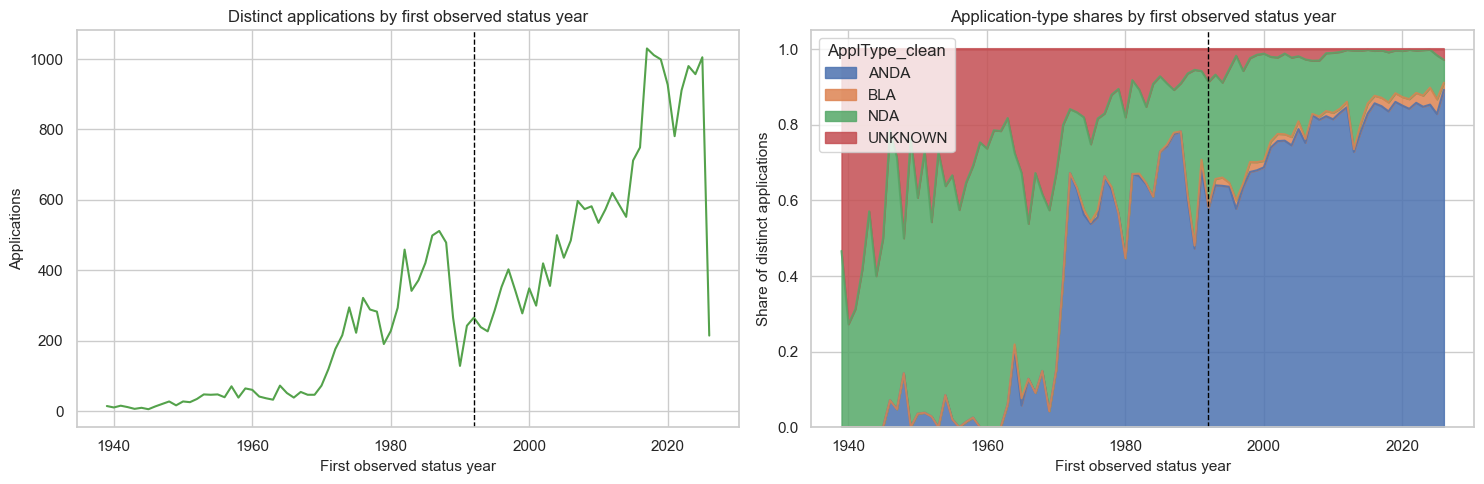

,metric,value
0,distinct applications,"27,662.000"
1,applications with any AP row,"26,539.000"
2,applications with any TA row,"1,201.000"
3,median submission rows per application,3.000
4,mean submission rows per application,6.910


In [13]:

application_panel = (
    fda.sort_values(["ApplNo", "SubmissionStatusDate"])
    .groupby("ApplNo", dropna=False)
    .agg(
        first_observed_status_year=("submission_status_year", "min"),
        last_observed_status_year=("submission_status_year", "max"),
        SponsorName=("SponsorName", first_nonmissing),
        ApplType_clean=("ApplType_clean", first_nonmissing),
        n_submission_rows=("SubmissionNo", "size"),
        any_approved=("is_approved", lambda s: s.fillna(False).any()),
        any_tentative=("is_tentative_approval", lambda s: s.fillna(False).any()),
    )
    .reset_index()
)
application_panel["ApplType_clean"] = application_panel["ApplType_clean"].fillna("UNKNOWN")

application_level_summary = pd.DataFrame({
    "metric": [
        "distinct applications",
        "applications with any AP row",
        "applications with any TA row",
        "median submission rows per application",
        "mean submission rows per application",
    ],
    "value": [
        len(application_panel),
        int(application_panel["any_approved"].sum()),
        int(application_panel["any_tentative"].sum()),
        float(application_panel["n_submission_rows"].median()),
        round(float(application_panel["n_submission_rows"].mean()), 2),
    ],
})

application_first_year = (
    application_panel.dropna(subset=["first_observed_status_year"])
    .groupby("first_observed_status_year")
    .size()
    .reset_index(name="applications")
)
application_first_year["first_observed_status_year"] = application_first_year["first_observed_status_year"].astype(int)

application_type_first_year = (
    application_panel.dropna(subset=["first_observed_status_year"])
    .groupby(["first_observed_status_year", "ApplType_clean"], dropna=False)
    .size()
    .reset_index(name="n")
)
application_type_first_year["first_observed_status_year"] = application_type_first_year["first_observed_status_year"].astype(int)
application_type_first_year["share_within_year"] = (
    application_type_first_year["n"]
    / application_type_first_year.groupby("first_observed_status_year")["n"].transform("sum")
)
application_type_first_year_pivot = application_type_first_year.pivot(index="first_observed_status_year", columns="ApplType_clean", values="share_within_year").fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(application_first_year["first_observed_status_year"], application_first_year["applications"], color="#54A24B")
axes[0].axvline(PDUFA_YEAR, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Distinct applications by first observed status year")
axes[0].set_xlabel("First observed status year")
axes[0].set_ylabel("Applications")

application_type_first_year_pivot.plot.area(ax=axes[1], alpha=0.85)
axes[1].axvline(PDUFA_YEAR, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Application-type shares by first observed status year")
axes[1].set_xlabel("First observed status year")
axes[1].set_ylabel("Share of distinct applications")
axes[1].legend(title="ApplType_clean", loc="upper left")

plt.tight_layout()
plt.show()

display(application_level_summary)



### Interpretation

This temporary application-level view is useful because it strips away repeated supplements and shows the breadth of distinct applications more directly. In that sense, it is often a better descriptive denominator than raw submission-event counts.

But it is still a sensitivity check rather than a replacement for the master panel. `first_observed_status_year` is only the first year visible in this processed status-based dataset, not a validated filing-year measure.



## Synthesis and next-step recommendations

### What this processed FDA data is actually good for

The processed backbone is well-suited for:

- describing the volume and composition of observed FDA **submission events** over time
- comparing `ORIG` and `SUPPL` activity
- examining the observed mix of `NDA`, `ANDA`, and `BLA` activity in the panel
- studying broad approval-related status patterns in an approval-centered FDA source
- identifying sponsor concentration and the density of regulatory activity around applications
- building narrower descriptive subsets such as `ORIG`, `AP`, or `ORIG + AP` without going back to raw text files

### What it is not sufficient to answer on its own

This FDA backbone is not enough, by itself, to answer:

- the full universe of unsuccessful FDA filings
- exact causal effects of PDUFA on approval behavior
- exact product-level submission histories for every row
- whether the drugs in question are controlled substances, and if so under what schedule

### Descriptive patterns that look especially promising

The notebook is designed to make a few substantive patterns visible:

- the panel is heavily supplement-driven, so unit-of-observation choices matter immediately
- the application-type mix appears to shift materially over time, especially toward `ANDA` activity in later years
- review-priority coding quality changes over time, so raw and cleaned fields should be distinguished carefully
- sponsor concentration is meaningful, but it looks different at the submission-event and application levels

### Most needed additional data layers

The next logical enrichment step is **DEA controlled-substance / schedule linkage**. The current FDA backbone tells us a lot about regulatory events, but it cannot yet identify which drugs are controlled substances or how the observed regulatory mix changes for scheduled drugs specifically.

### Recommended next steps

1. Proceed with DEA controlled-substance / schedule linkage as the next major enrichment layer.
2. Keep `data/processed/fda_backbone.csv` as the master FDA source and derive narrower analytic subsets downstream rather than replacing the master file.
3. For thesis descriptives, compare at least three views explicitly: the **full submission-event panel**, an **approval-oriented subset** such as `AP`, and a **newer-drug-oriented subset** such as `ORIG + AP`.
4. Consider deriving a lightweight application-level panel for some plots and denominators, but keep the caveat that first observed status year is not filing year.
5. Treat `ReviewPriority_raw` and the orphan-property signal as useful but imperfect variables that need cautious interpretation.
